In [6]:

# Updated Game Sessions Data Analysis (Practice vs Competitive)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("c.csv")

# Convert data types
df['game_mode'] = df['game_mode'].astype('category')

# Derived metrics
df['accuracy'] = df['correct_answers'] / df['total_questions'].replace(0, pd.NA)
df['wrong_per_correct'] = df['wrong_answers'] / df['correct_answers'].replace(0, pd.NA)
df['questions_per_minute'] = df['total_questions'] / (df['time_taken'] / 60).replace(0, pd.NA)

# Separate datasets
practice_df = df[df['game_mode'] == 'practice']
competitive_df = df[df['game_mode'].isin(['computer', 'pvp'])]


In [7]:
# Overview
print("Game Mode Counts:\n", df['game_mode'].value_counts(), "\n")

# Descriptive Stats
print("Overall Descriptive Stats by Mode:\n")
print(df.groupby('game_mode')[['correct_answers', 'wrong_answers', 'total_questions', 'accuracy', 'wrong_per_correct', 'questions_per_minute']].mean())


Game Mode Counts:
 game_mode
practice    130
computer     67
pvp          64
Name: count, dtype: int64 

Overall Descriptive Stats by Mode:

           correct_answers  wrong_answers  total_questions  accuracy  \
game_mode                                                              
computer         11.626866      20.537313         14.80597  0.791493   
practice         10.000000       6.615385         10.00000  1.000000   
pvp              15.187500      27.765625         31.71875  0.466288   

          wrong_per_correct  questions_per_minute  
game_mode                                          
computer           1.853917             38.979008  
practice           0.661538              8.729121  
pvp                1.916326             20.308880  


C:\Users\ernaf\AppData\Local\Temp/ipykernel_17840/2169177243.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('game_mode')[['correct_answers', 'wrong_answers', 'total_questions', 'accuracy', 'wrong_per_correct', 'questions_per_minute']].mean())


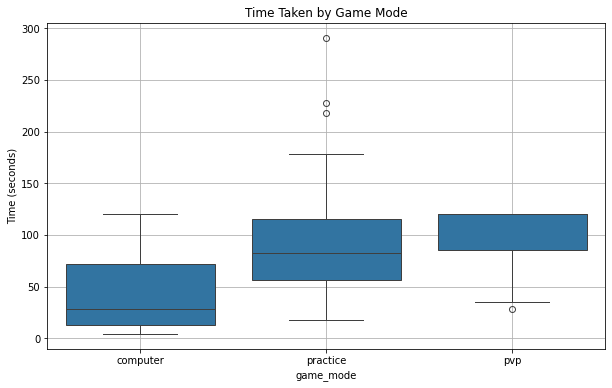

In [8]:
# Plot 1: Time Taken by Mode
plt.figure(figsize=(10, 6))
sns.boxplot(x='game_mode', y='time_taken', data=df)
plt.title("Time Taken by Game Mode")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()

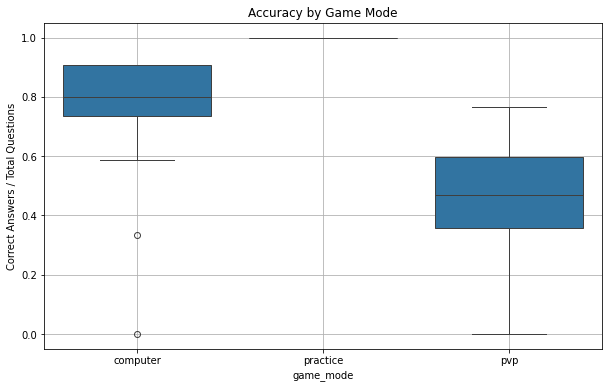

In [9]:
# Plot 2: Accuracy by Game Mode
plt.figure(figsize=(10, 6))
sns.boxplot(x='game_mode', y='accuracy', data=df)
plt.title("Accuracy by Game Mode")
plt.ylabel("Correct Answers / Total Questions")
plt.grid(True)
plt.show()

In [10]:
# Find rows where correct_answers > total_questions
invalid_rows = df[df['correct_answers'] > df['total_questions']]
print(f"Found {len(invalid_rows)} rows with more correct answers than total questions.")
display(invalid_rows)


Found 0 rows with more correct answers than total questions.


,session_id,time_taken,student_id,topic_id,game_mode,opponent_id,created_at,correct_answers,wrong_answers,total_questions,winner,points,accuracy,wrong_per_correct,questions_per_minute


Game Mode Counts:
 game_mode
practice    130
computer     67
pvp          64
Name: count, dtype: int64

Descriptive Statistics by Game Mode:
           correct_answers                                                      \
                    count       mean       std   min    25%   50%   75%   max   
game_mode                                                                       
computer             67.0  11.626866  3.054236   0.0  10.00  11.0  13.0  18.0   
practice            130.0  10.000000  0.000000  10.0  10.00  10.0  10.0  10.0   
pvp                  64.0  15.187500  7.613428   0.0   9.75  15.5  21.0  35.0   

          wrong_answers             ... time_taken        accuracy            \
                  count       mean  ...        75%    max    count      mean   
game_mode                           ...                                        
computer           67.0  20.537313  ...       71.5  120.0     67.0  0.791493   
practice          130.0   6.615385  ...      115.0 

C:\Users\ernaf\AppData\Local\Temp/ipykernel_17840/1828294848.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stats = df.groupby('game_mode')[['correct_answers', 'wrong_answers', 'time_taken', 'accuracy']].describe()


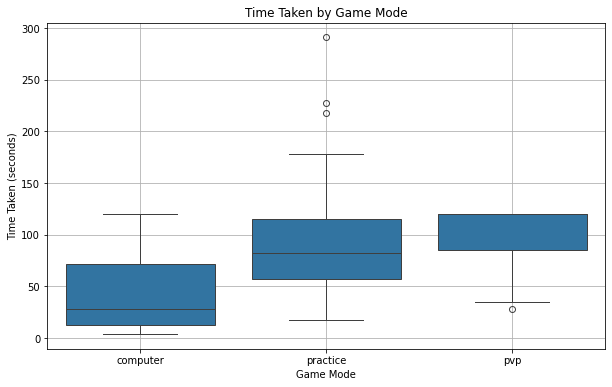

In [11]:
# 1. Overview of Game Modes
mode_counts = df['game_mode'].value_counts()
print("Game Mode Counts:\n", mode_counts)

# 2. Descriptive Statistics by Game Mode
grouped_stats = df.groupby('game_mode')[['correct_answers', 'wrong_answers', 'time_taken', 'accuracy']].describe()
print("\nDescriptive Statistics by Game Mode:\n", grouped_stats)

# 3. Plot: Time Taken Distribution by Game Mode
plt.figure(figsize=(10, 6))
sns.boxplot(x='game_mode', y='time_taken', data=df)
plt.title("Time Taken by Game Mode")
plt.ylabel("Time Taken (seconds)")
plt.xlabel("Game Mode")
plt.grid(True)
plt.show()


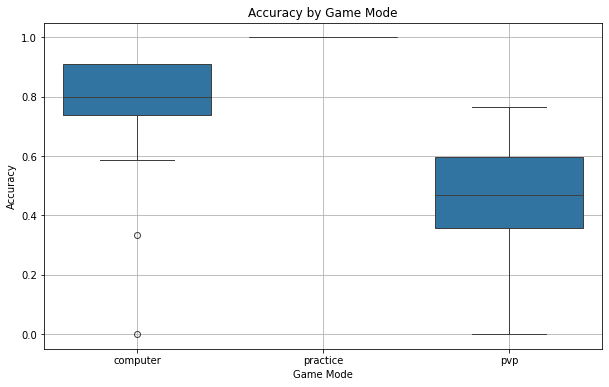

In [12]:
# 4. Plot: Accuracy by Game Mode
plt.figure(figsize=(10, 6))
sns.boxplot(x='game_mode', y='accuracy', data=df)
plt.title("Accuracy by Game Mode")
plt.ylabel("Accuracy")
plt.xlabel("Game Mode")
plt.grid(True)
plt.show()






# 5. Plot: Correct vs. Wrong Answers by Game Mode
agg_answers = df.groupby('game_mode')[['correct_answers', 'wrong_answers']].mean().reset_index()
agg_answers.plot(x='game_mode', kind='bar', stacked=False, figsize=(10, 6))
plt.title("Average Correct and Wrong Answers by Game Mode")
plt.ylabel("Average Number of Answers")
plt.grid(True)
plt.show()

# 6. Optional: Save to CSV for external visualization
df.to_csv("analyzed_game_sessions.csv", index=False)


In [2]:
details_df = pd.read_csv("game_question_details.csv")

# Convert `created_at` to datetime for proper sorting
details_df['created_at'] = pd.to_datetime(details_df['created_at'])

# Sort by session, question, and created_at to keep the first response
filtered_df = details_df.sort_values(by=['session_id', 'question_id']) \
                        .drop_duplicates(subset=['session_id', 'question_id', 'selected_answer'], keep='first')

# View the cleaned dataframe
display(filtered_df)


# Save the cleaned and filtered data
filtered_df.to_csv("game_question_details_filtered.csv", index=False)


,detail_id,session_id,question_id,selected_answer,is_correct,response_time,created_at
10,458,260,278,4,False,16,2025-06-04 07:43:32.130322
11,459,260,278,2,True,16,2025-06-04 07:43:32.459816
8,456,260,279,1,False,10,2025-06-04 07:43:25.797713
9,457,260,279,2,True,10,2025-06-04 07:43:26.316724
6,454,260,295,2,False,7,2025-06-04 07:43:23.118856
...,...,...,...,...,...,...,...
3070,3518,648,262,4,False,5,2025-06-12 18:00:25.082936
3065,3513,648,283,1,False,2,2025-06-12 18:00:22.459859
3066,3514,648,283,3,False,2,2025-06-12 18:00:22.873639
3067,3515,648,283,4,False,3,2025-06-12 18:00:23.303129
